<h1 style='color:white;background:#E23744;padding:15px;border-radius:8px;text-align:center'>🍽️ Zomato Restaurant Recommendation System</h1>
<h3 style='color:white;text-align:center'>Capstone Project-2</h3>
<h3 style='color:white;text-align:center'>Content-Based Recommender System using NLP</h3>
<h4 style='color:white;text-align:center'>Author: <b>Madhusudan Manna from batch-13,IIT,Guwahati</b></h4>
<p style='color:white;text-align:center'>Dataset: Zomato Bangalore Restaurants | <a style='color:#ffaaaa' href='https://www.kaggle.com/code/chirag9073/zomato-recommendation-system'>Kaggle Reference</a></p>

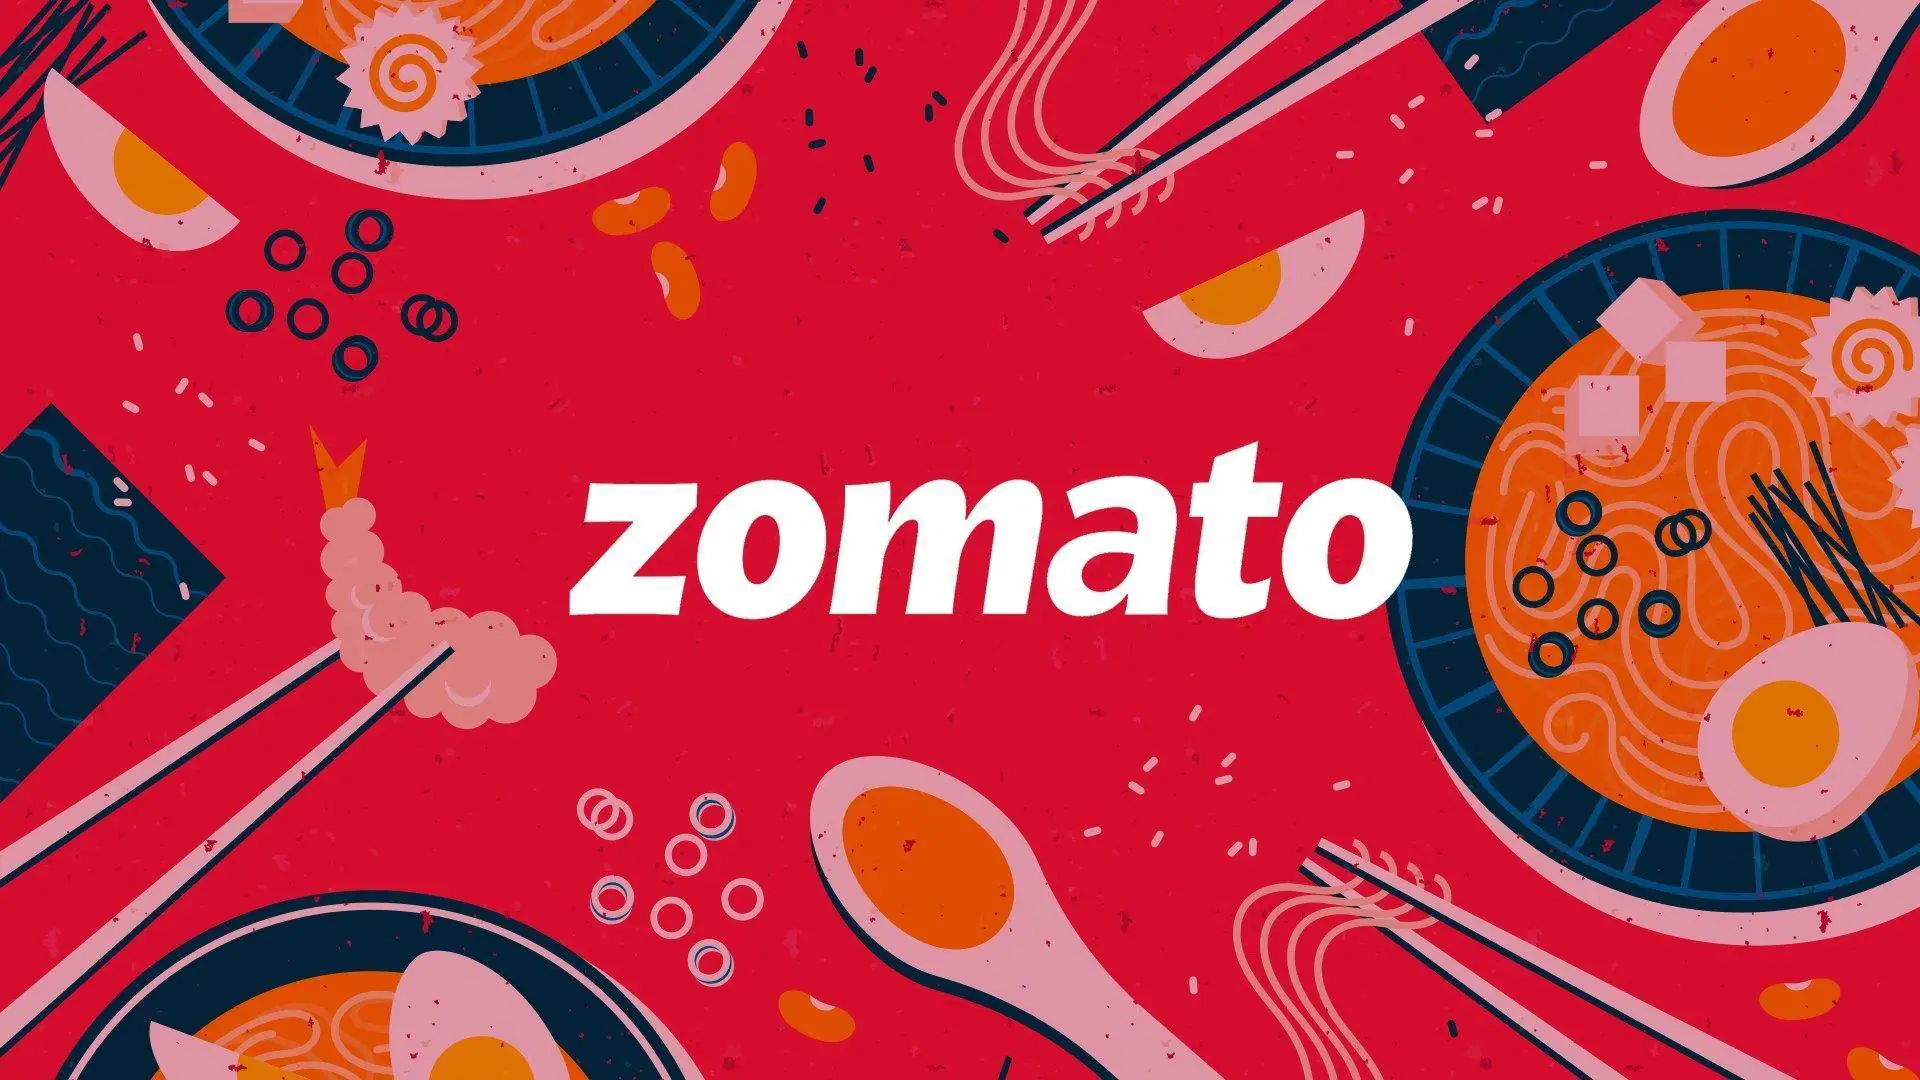

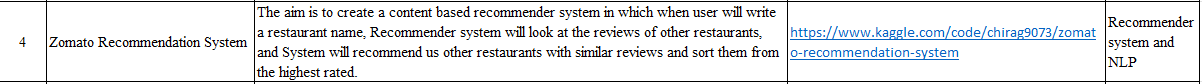

---
## <span style='color:white'>📌 Objective</span>
<span style='color:white'>The aim is to create a <b>content-based recommender system</b> where a user writes a restaurant name, and the system looks at the <b>reviews</b> of other restaurants and recommends those with <b>similar reviews</b>, sorted from the <b>highest rated</b>.</span>

---
## <span style='color:white'>Task 1: Import Required Libraries</span>

In [1]:
# [35mImporting all necessary libraries[0m
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print('\033[35mLibraries imported: numpy, pandas, matplotlib, seaborn, re, pickle, sklearn\033[0m')
print('\033[35mAll libraries imported successfully!\033[0m')

Libraries imported: numpy, pandas, matplotlib, seaborn, re, pickle, sklearn
All libraries imported successfully!


---
## <span style='color:white'>Task 2: Load the Dataset</span>
<span style='color:white'>Dataset: <b>Zomato Bangalore Restaurants</b> (51,717 rows × 17 columns, ~547 MB)<br>
We use chunked reading to avoid out-of-memory errors and load only the required columns.</span>

In [2]:
# [35mLoad zomato.csv using chunked reading — safe for the 547 MB file[0m
NEEDED = ['name', 'cuisines', 'rate', 'reviews_list',
          'rest_type', 'location', 'approx_cost(for two people)', 'votes']

chunks = []
for chunk in pd.read_csv('zomato.csv', encoding='latin-1',
                         on_bad_lines='skip', low_memory=True,
                         chunksize=10000):
    chunks.append(chunk[NEEDED])

df_raw = pd.concat(chunks, ignore_index=True)
df_raw.columns = ['name','cuisines','rate','reviews_list',
                  'rest_type','location','cost','votes']

print('\033[35mDataset loaded successfully!\033[0m')
print('\033[35mShape of dataset:\033[0m', df_raw.shape)
df_raw.head()

Dataset loaded successfully!
Shape of dataset: (51717, 8)


,name,cuisines,rate,reviews_list,rest_type,location,cost,votes
0,Jalsa,"North Indian, Mughlai, Chinese",4.1/5,"[('Rated 4.0', 'RATED\n A beautiful place to ...",Casual Dining,Banashankari,800,775
1,Spice Elephant,"Chinese, North Indian, Thai",4.1/5,"[('Rated 4.0', 'RATED\n Had been here for din...",Casual Dining,Banashankari,800,787
2,San Churro Cafe,"Cafe, Mexican, Italian",3.8/5,"[('Rated 3.0', ""RATED\n Ambience is not that ...","Cafe, Casual Dining",Banashankari,800,918
3,Addhuri Udupi Bhojana,"South Indian, North Indian",3.7/5,"[('Rated 4.0', ""RATED\n Great food and proper...",Quick Bites,Banashankari,300,88
4,Grand Village,"North Indian, Rajasthani",3.8/5,"[('Rated 4.0', 'RATED\n Very good restaurant ...",Casual Dining,Basavanagudi,600,166


---
## <span style='color:white'>Task 3: Explore the Dataset</span>

In [3]:
# [35mDataset shape and data types[0m
print('\033[35mShape of dataset:\033[0m', df_raw.shape)
print('\033[35mData Types:\033[0m')
print(df_raw.dtypes)

Shape of dataset: (51717, 8)
Data Types:
name              str
cuisines          str
rate              str
reviews_list      str
rest_type         str
location          str
cost              str
votes           int64
dtype: object


In [ ]:
# [35mColumn names[0m
print('\033[35mColumn Names:\033[0m')
print(df_raw.columns.tolist())

In [4]:
# [35mFirst 5 rows of the dataset[0m
print('\033[35mFirst 5 rows:\033[0m')
df_raw.head()

First 5 rows:


,name,cuisines,rate,reviews_list,rest_type,location,cost,votes
0,Jalsa,"North Indian, Mughlai, Chinese",4.1/5,"[('Rated 4.0', 'RATED\n A beautiful place to ...",Casual Dining,Banashankari,800,775
1,Spice Elephant,"Chinese, North Indian, Thai",4.1/5,"[('Rated 4.0', 'RATED\n Had been here for din...",Casual Dining,Banashankari,800,787
2,San Churro Cafe,"Cafe, Mexican, Italian",3.8/5,"[('Rated 3.0', ""RATED\n Ambience is not that ...","Cafe, Casual Dining",Banashankari,800,918
3,Addhuri Udupi Bhojana,"South Indian, North Indian",3.7/5,"[('Rated 4.0', ""RATED\n Great food and proper...",Quick Bites,Banashankari,300,88
4,Grand Village,"North Indian, Rajasthani",3.8/5,"[('Rated 4.0', 'RATED\n Very good restaurant ...",Casual Dining,Basavanagudi,600,166


In [5]:
# [35mDataset Info — non-null counts and dtypes[0m
print('\033[35mDataset Info:\033[0m')
df_raw.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   name          51717 non-null  str  
 1   cuisines      51672 non-null  str  
 2   rate          43942 non-null  str  
 3   reviews_list  51717 non-null  str  
 4   rest_type     51490 non-null  str  
 5   location      51696 non-null  str  
 6   cost          51371 non-null  str  
 7   votes         51717 non-null  int64
dtypes: int64(1), str(7)
memory usage: 530.2 MB


In [6]:
# [35mMissing values per column[0m
print('\033[35mMissing Values in each column:\033[0m')
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

Missing Values in each column:
              Missing Count  Missing %
name                      0       0.00
cuisines                 45       0.09
rate                   7775      15.03
reviews_list              0       0.00
rest_type               227       0.44
location                 21       0.04
cost                    346       0.67
votes                     0       0.00


In [ ]:
# [35mDescriptive statistics for numeric columns[0m
print('\033[35mDescriptive Statistics:\033[0m')
df_raw[['votes']].describe()

In [7]:
# [35mUnique value counts for categorical columns[0m
print('\033[35mUnique value counts:\033[0m')
for col in ['location','rest_type','cuisines','rate']:
    print(f'  {col}: {df_raw[col].nunique()} unique values')

Unique value counts:
  location: 93 unique values
  rest_type: 93 unique values
  cuisines: 2723 unique values
  rate: 64 unique values


---
## <span style='color:white'>Task 4: Data Preprocessing</span>
<span style='color:white'>Steps:<br>
1. Remove duplicate restaurant names<br>
2. Drop rows with missing essential fields<br>
3. Clean the <code>rate</code> column — convert '4.1/5' → 4.1, handle 'NEW' and '-' values<br>
4. Clean the <code>cost</code> column — remove commas, convert to numeric</span>

In [8]:
# [35mStep 4a — Work on a clean copy, remove duplicate restaurant names[0m
df = df_raw.copy()
print('\033[35mShape before dedup:\033[0m', df.shape)
df.drop_duplicates(subset=['name'], keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)
print('\033[35mShape after removing duplicate names:\033[0m', df.shape)

Shape before dedup: (51717, 8)
Shape after removing duplicate names: (8792, 8)


In [9]:
# [35mStep 4b — Drop rows where essential fields are missing[0m
df.dropna(subset=['name','reviews_list'], inplace=True)
df.reset_index(drop=True, inplace=True)
print('\033[35mShape after dropping null reviews/name:\033[0m', df.shape)

Shape after dropping null reviews/name: (8792, 8)


In [10]:
# [35mStep 4c — Clean rate column[0m
# Original format: '4.1/5', '3.9 /5', 'NEW', '-', NaN
# Target: numeric float like 4.1
def clean_rate(r):
    try:
        r = str(r).strip()
        if r in ['NEW', '-', 'nan', '']:
            return np.nan
        return float(r.split('/')[0].strip())
    except:
        return np.nan

df['rate'] = df['rate'].apply(clean_rate)
df.dropna(subset=['rate'], inplace=True)
df.reset_index(drop=True, inplace=True)
print('\033[35mRate column cleaned. Shape after dropping invalid rates:\033[0m', df.shape)
print('\033[35mSample rate values:\033[0m')
print(df['rate'].head(10).tolist())

Rate column cleaned. Shape after dropping invalid rates: (6332, 8)
Sample rate values:
[4.1, 4.1, 3.8, 3.7, 3.8, 3.8, 3.6, 4.6, 4.0, 4.2]


In [11]:
# [35mStep 4d — Clean cost column (remove commas, convert to numeric)[0m
df['cost'] = df['cost'].astype(str).str.replace(',','',regex=False)
df['cost'] = pd.to_numeric(df['cost'], errors='coerce')
print('\033[35mCost column cleaned. Null cost rows:\033[0m', df['cost'].isna().sum())
print('\033[35mFinal dataset shape:\033[0m', df.shape)
df.head()

Cost column cleaned. Null cost rows: 24
Final dataset shape: (6332, 8)


,name,cuisines,rate,reviews_list,rest_type,location,cost,votes
0,Jalsa,"North Indian, Mughlai, Chinese",4.1,"[('Rated 4.0', 'RATED\n A beautiful place to ...",Casual Dining,Banashankari,800.0,775
1,Spice Elephant,"Chinese, North Indian, Thai",4.1,"[('Rated 4.0', 'RATED\n Had been here for din...",Casual Dining,Banashankari,800.0,787
2,San Churro Cafe,"Cafe, Mexican, Italian",3.8,"[('Rated 3.0', ""RATED\n Ambience is not that ...","Cafe, Casual Dining",Banashankari,800.0,918
3,Addhuri Udupi Bhojana,"South Indian, North Indian",3.7,"[('Rated 4.0', ""RATED\n Great food and proper...",Quick Bites,Banashankari,300.0,88
4,Grand Village,"North Indian, Rajasthani",3.8,"[('Rated 4.0', 'RATED\n Very good restaurant ...",Casual Dining,Basavanagudi,600.0,166


---
## <span style='color:white'>Task 5: Exploratory Data Analysis (EDA)</span>

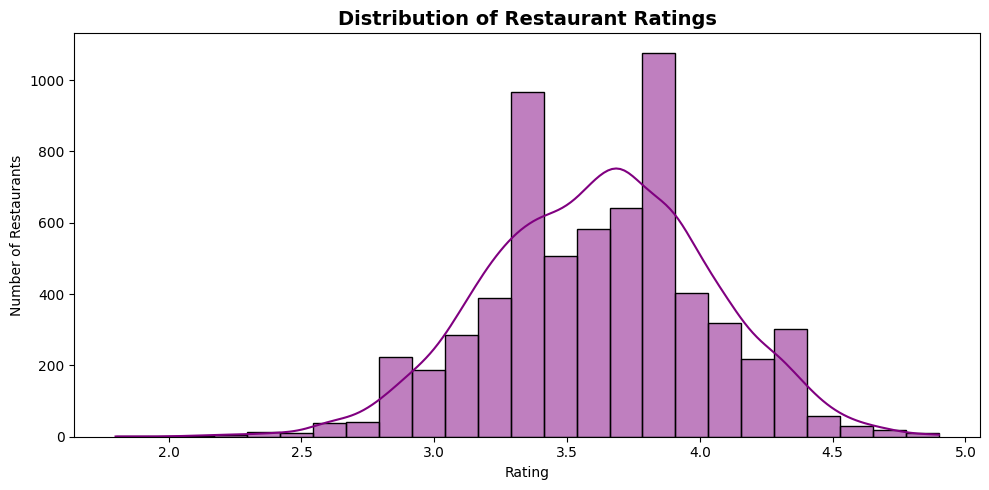

Most restaurants are rated between 3.5 and 4.2


In [12]:
# [35mEDA 1 — Distribution of Restaurant Ratings[0m
plt.figure(figsize=(10, 5))
sns.histplot(df['rate'], bins=25, kde=True, color='purple')
plt.title('Distribution of Restaurant Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.show()
print('\033[35mMost restaurants are rated between 3.5 and 4.2\033[0m')

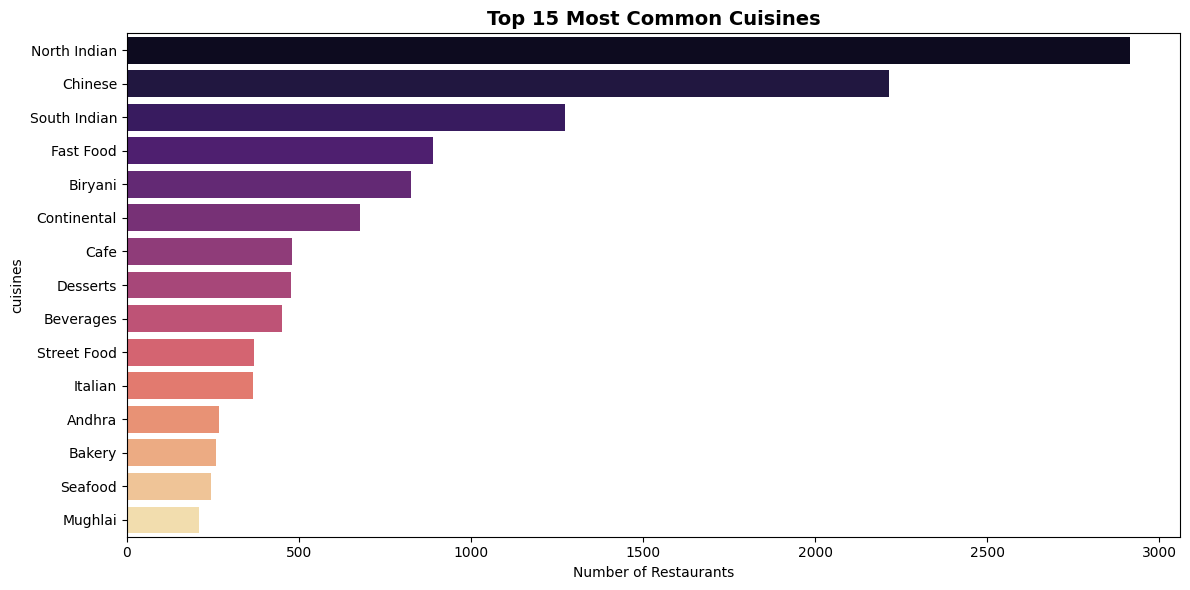

North Indian and Chinese are the most popular cuisines


In [13]:
# [35mEDA 2 — Top 15 Most Common Cuisines[0m
cuisine_series = df['cuisines'].dropna().str.split(',').explode().str.strip()
top_cuisines = cuisine_series.value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette='magma')
plt.title('Top 15 Most Common Cuisines', fontsize=14, fontweight='bold')
plt.xlabel('Number of Restaurants')
plt.tight_layout()
plt.show()
print('\033[35mNorth Indian and Chinese are the most popular cuisines\033[0m')

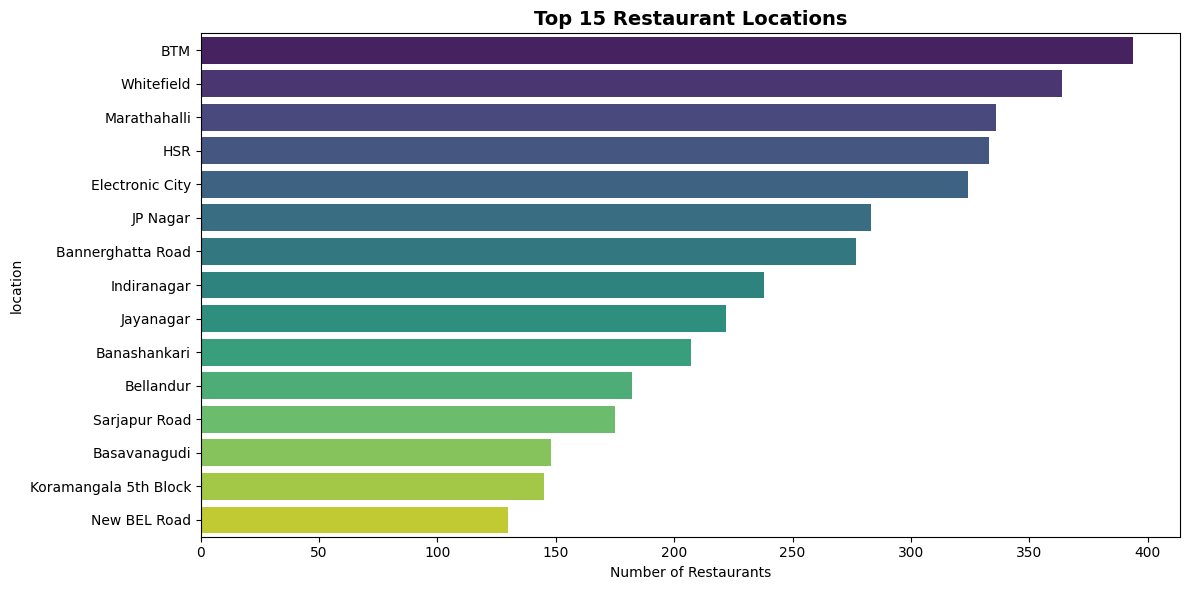

BTM and Koramangala have the highest restaurant density


In [14]:
# [35mEDA 3 — Top 15 Restaurant Locations in Bangalore[0m
top_locs = df['location'].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_locs.values, y=top_locs.index, palette='viridis')
plt.title('Top 15 Restaurant Locations', fontsize=14, fontweight='bold')
plt.xlabel('Number of Restaurants')
plt.tight_layout()
plt.show()
print('\033[35mBTM and Koramangala have the highest restaurant density\033[0m')

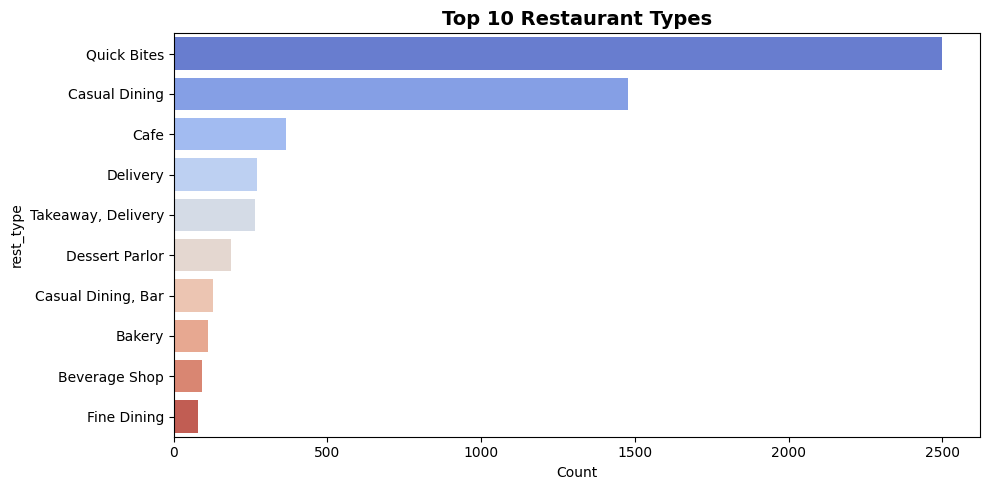

Quick Bites and Casual Dining dominate the restaurant landscape


In [15]:
# [35mEDA 4 — Top 10 Restaurant Types[0m
top_types = df['rest_type'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_types.values, y=top_types.index, palette='coolwarm')
plt.title('Top 10 Restaurant Types', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.tight_layout()
plt.show()
print('\033[35mQuick Bites and Casual Dining dominate the restaurant landscape\033[0m')

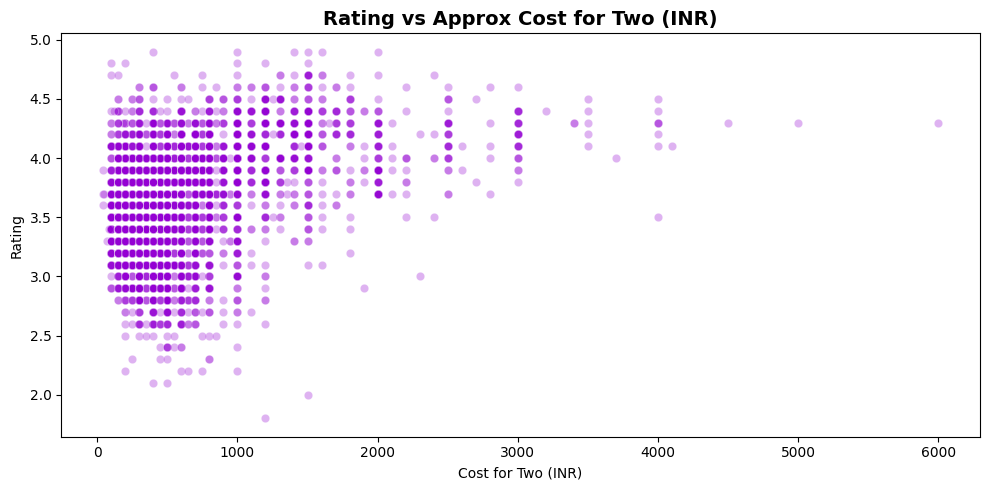

Higher cost restaurants tend to have slightly higher ratings


In [16]:
# [35mEDA 5 — Rating vs Approx Cost for Two (scatter)[0m
df_plot = df.dropna(subset=['cost'])

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_plot, x='cost', y='rate', alpha=0.3, color='darkviolet')
plt.title('Rating vs Approx Cost for Two (INR)', fontsize=14, fontweight='bold')
plt.xlabel('Cost for Two (INR)')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()
print('\033[35mHigher cost restaurants tend to have slightly higher ratings\033[0m')

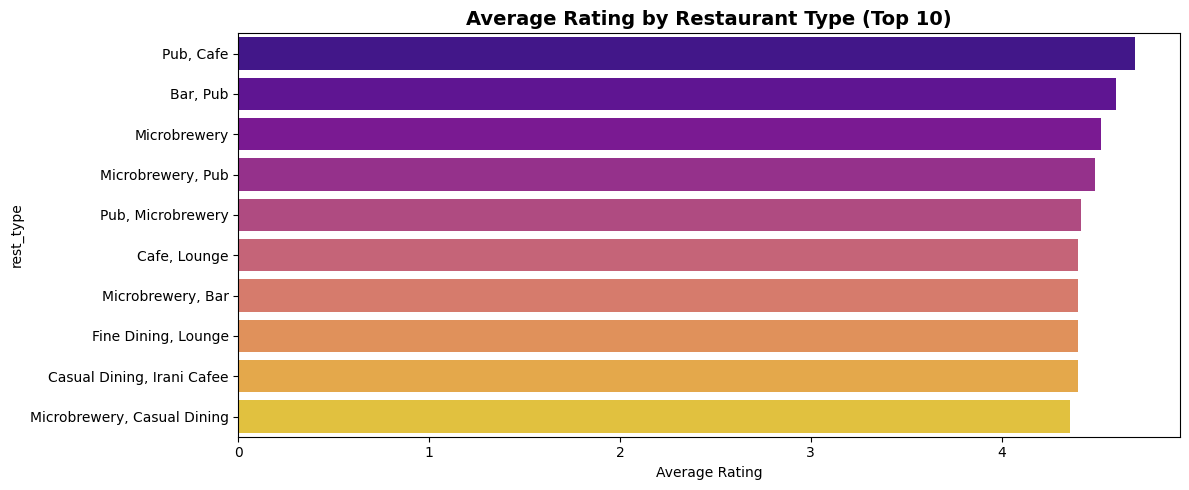

Average rating by restaurant type plotted!


In [17]:
# [35mEDA 6 — Average Rating by Restaurant Type[0m
avg_rate = df.groupby('rest_type')['rate'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=avg_rate.values, y=avg_rate.index, palette='plasma')
plt.title('Average Rating by Restaurant Type (Top 10)', fontsize=14, fontweight='bold')
plt.xlabel('Average Rating')
plt.tight_layout()
plt.show()
print('\033[35mAverage rating by restaurant type plotted!\033[0m')

---
## <span style='color:white'>Task 6: Parse & Clean Review Text (NLP Preprocessing)</span>
<span style='color:white'>The <code>reviews_list</code> column is a stringified list of tuples:<br>
<code>[('Rated 4.0', 'RATED\n  Great food...'), ('Rated 3.0', 'Average place...')]</code><br>
We extract the actual review sentences, then clean the text using NLP techniques:</span>
<ul style='color:white'><li>Lowercase conversion</li><li>Remove HTML entities (&amp;nbsp;)</li><li>Remove special characters and digits</li><li>Remove extra whitespace</li></ul>

In [18]:
# [35mStep 6a — Extract actual review text from the stringified list-of-tuples[0m
def extract_review_text(raw):
    """
    Input : "[('Rated 4.0', 'RATED\\n  Great food...'), ...]"
    Output: 'Great food...'
    Approach: regex to grab content inside single quotes, skip short 'Rated X.X' labels
    """
    try:
        parts = re.findall(r"'(.*?)'", str(raw), re.DOTALL)
        texts = [p for p in parts if len(p) > 20]  # skip short rating labels
        return ' '.join(texts) if texts else ''
    except:
        return ''

print('\033[35mParsing review text from all restaurants...\033[0m')
df['parsed_reviews'] = df['reviews_list'].apply(extract_review_text)
print('\033[35mParsing complete!\033[0m')
print('\033[35mSample parsed review:\033[0m')
print(df['parsed_reviews'].iloc[0][:200])

Parsing review text from all restaurants...
Parsing complete!
Sample parsed review:
RATED\n  A beautiful place to dine in.The interiors take you back to the Mughal era. The lightings are just perfect.We went there on the occasion of Christmas and so they had only limited items availa


In [19]:
# [35mStep 6b — Clean parsed reviews using fast vectorised Pandas operations[0m
df['cleaned_reviews'] = (
    df['parsed_reviews']
    .str.lower()                                          # lowercase
    .str.replace(r'rated\s*\d[\d\.]*', ' ', regex=True) # remove 'rated 4.0'
    .str.replace(r'&nbsp;', ' ', regex=False)             # remove HTML entities
    .str.replace(r'\\n', ' ', regex=False)               # remove newline escapes
    .str.replace(r'[^a-z\s]', ' ', regex=True)           # keep only letters
    .str.replace(r'\s+', ' ', regex=True)                # collapse spaces
    .str.strip()
)

# Drop rows where cleaned review is too short to be meaningful
df = df[df['cleaned_reviews'].str.len() > 30].reset_index(drop=True)
print('\033[35mText cleaning done!\033[0m')
print('\033[35mRestaurants with valid reviews:\033[0m', len(df))
print('\033[35mSample cleaned review:\033[0m')
print(df['cleaned_reviews'].iloc[0][:200])

Text cleaning done!
Restaurants with valid reviews: 5838
Sample cleaned review:
rated n a beautiful place to dine in the interiors take you back to the mughal era the lightings are just perfect we went there on the occasion of christmas and so they had only limited items availabl


In [20]:
# [35mPreview: original vs cleaned reviews side by side[0m
print('\033[35mComparison: reviews_list vs cleaned_reviews\033[0m')
df[['name','cleaned_reviews']].head(3)

Comparison: reviews_list vs cleaned_reviews


,name,cleaned_reviews
0,Jalsa,rated n a beautiful place to dine in the inter...
1,Spice Elephant,rated n had been here for dinner with family t...
2,San Churro Cafe,s not a pocket friendly cafe and the quantity ...


---
## <span style='color:white'>Task 7: TF-IDF Vectorization</span>
<span style='color:white'><b>TF-IDF</b> (Term Frequency–Inverse Document Frequency) converts review text into numeric vectors.<br>
- <b>TF</b>: How often a word appears in a restaurant's reviews<br>
- <b>IDF</b>: Penalises words that appear in almost every restaurant<br>
- Result: A sparse matrix where each row = one restaurant, each column = one word's importance score</span>

In [21]:
# [35mApply TF-IDF Vectorizer on cleaned reviews[0m
# max_features=3000  — keep top 3000 words by term frequency
# stop_words='english' — remove common English words (the, is, and...)
# min_df=2            — ignore words that appear in < 2 restaurants
# dtype=float32       — halves memory usage vs float64

tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 1),
    stop_words='english',
    min_df=2,
    dtype=np.float32
)

tfidf_matrix = tfidf.fit_transform(df['cleaned_reviews'])

print('\033[35mTF-IDF Matrix Shape:\033[0m', tfidf_matrix.shape)
print('\033[35mRows = Restaurants | Columns = Words\033[0m')
print('\033[35mSample feature names:\033[0m', tfidf.get_feature_names_out()[:20].tolist())
print('\033[35mTF-IDF Vectorization completed successfully!\033[0m')

TF-IDF Matrix Shape: (5838, 3000)
Rows = Restaurants | Columns = Words
Sample feature names: ['aaloo', 'aam', 'able', 'absolute', 'absolutely', 'abt', 'ac', 'accept', 'acceptable', 'accepted', 'accessible', 'accidentally', 'accommodate', 'accompanied', 'accompaniment', 'according', 'achari', 'actual', 'actually', 'add']
TF-IDF Vectorization completed successfully!


---
## <span style='color:white'>Task 8: Compute Cosine Similarity</span>
<span style='color:white'><b>Cosine Similarity</b> measures the angle between two TF-IDF vectors.<br>
- Score = 1.0 → identical review content<br>
- Score = 0.0 → completely different review content<br>
We compute this for every pair of restaurants, producing an N×N similarity matrix.<br>
Batched computation avoids out-of-memory errors on large datasets.</span>

In [22]:
# [35mCompute Cosine Similarity matrix in batches to avoid memory overflow[0m
n = tfidf_matrix.shape[0]
BATCH = 2000  # process 2000 rows at a time
cosine_sim = np.zeros((n, n), dtype=np.float32)

print('\033[35mComputing cosine similarity...\033[0m')
for start in range(0, n, BATCH):
    end = min(start + BATCH, n)
    cosine_sim[start:end] = cosine_similarity(tfidf_matrix[start:end], tfidf_matrix)
    print(f'  \033[35mProcessed {end}/{n} rows ({int(end/n*100)}% done)\033[0m')

print('\033[35mCosine Similarity Matrix Shape:\033[0m', cosine_sim.shape)
print('\033[35mSample similarity scores (row 0 top 5):\033[0m',
      sorted(cosine_sim[0], reverse=True)[:5])
print('\033[35mCosine similarity computed successfully!\033[0m')

Computing cosine similarity...
  Processed 2000/5838 rows (34% done)
  Processed 4000/5838 rows (68% done)
  Processed 5838/5838 rows (100% done)
Cosine Similarity Matrix Shape: (5838, 5838)
Sample similarity scores (row 0 top 5): [np.float32(0.9999999), np.float32(0.44945556), np.float32(0.44539618), np.float32(0.43810335), np.float32(0.42986232)]
Cosine similarity computed successfully!


---
## <span style='color:white'>Task 9: Build the Recommendation Function</span>
<span style='color:white'>This function:<br>
1. Takes a restaurant name as input<br>
2. Finds its index in the cosine similarity matrix<br>
3. Retrieves similarity scores with all other restaurants<br>
4. Returns the top N most similar restaurants <b>sorted by highest rating first</b></span>

In [23]:
# [35mCreate index series: restaurant name (lowercase) → row index in cosine_sim[0m
indices = pd.Series(df.index, index=df['name'].str.lower()).drop_duplicates()
print('\033[35mIndex series created. Total restaurants indexed:\033[0m', len(indices))
print('\033[35mSample entries:\033[0m')
print(indices.head(5))

Index series created. Total restaurants indexed: 5838
Sample entries:
name
jalsa                    0
spice elephant           1
san churro cafe          2
addhuri udupi bhojana    3
grand village            4
dtype: int64


In [24]:
# [35mContent-Based Recommendation Function[0m
def recommend_restaurants(restaurant_name, top_n=10):
    """
    Recommends restaurants similar to the given restaurant name.
    Similarity is based on TF-IDF cosine similarity of review text.
    Results are sorted by highest rating first.

    Parameters:
        restaurant_name (str) : name of the query restaurant
        top_n          (int)  : number of recommendations to return

    Returns:
        pd.DataFrame : top N similar restaurants sorted by rating desc
    """
    name_lower = restaurant_name.strip().lower()

    # Check if restaurant exists in our index
    if name_lower not in indices:
        print(f'\033[35mRestaurant "{restaurant_name}" not found in dataset.\033[0m')
        print('\033[35mTip: Use df["name"].str.contains("keyword") to search.\033[0m')
        return None

    idx = indices[name_lower]

    # Get similarity scores for all restaurants vs. the query restaurant
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort by similarity score descending; skip index 0 (the restaurant itself)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1 : top_n + 1]

    # Get row indices of recommended restaurants
    rest_indices = [s[0] for s in sim_scores]

    # Build result DataFrame
    result = df.iloc[rest_indices][['name','cuisines','rate',
                                    'rest_type','location','cost','votes']].copy()
    result['similarity_score'] = [round(s[1], 4) for s in sim_scores]

    # Sort by rating descending (highest rated first)
    result = result.sort_values('rate', ascending=False).reset_index(drop=True)
    result.index += 1  # start rank from 1
    return result

print('\033[35mRecommendation function defined successfully!\033[0m')

Recommendation function defined successfully!


---
## <span style='color:white'>Task 10: Test the Recommendation System</span>

In [25]:
# [35mTest 1 — First restaurant in the dataset[0m
sample1 = df['name'].iloc[0]
print(f'\033[35mInput Restaurant: {sample1}\033[0m')
print('\033[35m' + '─'*55 + '\033[0m')
result1 = recommend_restaurants(sample1, top_n=10)
print('\033[35mTop 10 Recommended Restaurants (sorted by highest rating):\033[0m')
result1

Input Restaurant: Jalsa
───────────────────────────────────────────────────────
Top 10 Recommended Restaurants (sorted by highest rating):


,name,cuisines,rate,rest_type,location,cost,votes,similarity_score
1,Buff Buffet Buff,"North Indian, Chinese, Continental, Thai, Salad",4.5,"Casual Dining, Bar",Koramangala 5th Block,1500.0,3125,0.4299
2,Atithi,"North Indian, Chinese, Street Food",3.9,Casual Dining,HSR,800.0,224,0.4233
3,Curry with a 'K' - St. Mark's Hotel,"North Indian, Mughlai, Hyderabadi",3.9,Casual Dining,St. Marks Road,1400.0,89,0.4111
4,West Wood,"North Indian, Chinese, Continental",3.7,Casual Dining,Seshadripuram,1000.0,113,0.4079
5,Cafe @ Elanza,"Chinese, North Indian, Cafe",3.7,"Casual Dining, Cafe",Richmond Road,1000.0,145,0.4257
6,Nouvelle Garden,"North Indian, Continental, Italian",3.7,Casual Dining,JP Nagar,900.0,202,0.4381
7,The Onyx - The HHI Select Bengaluru,"North Indian, Chinese, Continental",3.3,Casual Dining,JP Nagar,950.0,177,0.4454
8,Flavours - Octave Hotel & Spa,"North Indian, Chinese",3.0,Casual Dining,Sarjapur Road,700.0,197,0.4495
9,Paprica,"North Indian, Chinese",2.6,"Casual Dining, Bar",Marathahalli,1200.0,118,0.4111
10,Dal Tadkaa,North Indian,2.5,Casual Dining,Banashankari,500.0,247,0.4189


In [26]:
# [35mTest 2 — Another well-known restaurant[0m
sample2 = df['name'].iloc[4]
print(f'\033[35mInput Restaurant: {sample2}\033[0m')
print('\033[35m' + '─'*55 + '\033[0m')
result2 = recommend_restaurants(sample2, top_n=10)
print('\033[35mTop 10 Recommended Restaurants (sorted by highest rating):\033[0m')
result2

Input Restaurant: Grand Village
───────────────────────────────────────────────────────
Top 10 Recommended Restaurants (sorted by highest rating):


,name,cuisines,rate,rest_type,location,cost,votes,similarity_score
1,The Black Pearl,"North Indian, European, Mediterranean, BBQ",4.8,"Casual Dining, Bar",Marathahalli,1500.0,7023,0.2375
2,Feast - Sheraton Grand Bengaluru Whitefield Ho...,"Continental, Asian, South Indian, North Indian",4.5,Fine Dining,Whitefield,2500.0,523,0.2448
3,Deja Vu Resto Bar,"North Indian, Italian",4.4,Pub,Bannerghatta Road,900.0,2487,0.2555
4,JW Kitchen - JW Marriott Bengaluru,"North Indian, Continental, Italian",4.4,Fine Dining,Lavelle Road,2200.0,2111,0.2375
5,24th Main,"North Indian, South Indian, Chinese",4.1,Casual Dining,JP Nagar,800.0,1234,0.2649
6,Amritsari Kulcha Land,North Indian,4.1,Quick Bites,JP Nagar,300.0,260,0.2828
7,Village - The Soul of India,"North Indian, Lucknowi, Gujarati, Maharashtria...",3.9,Casual Dining,Sarjapur Road,1100.0,1225,0.2716
8,Atithi,"North Indian, Chinese, Street Food",3.9,Casual Dining,HSR,800.0,224,0.2548
9,Curry with a 'K' - St. Mark's Hotel,"North Indian, Mughlai, Hyderabadi",3.9,Casual Dining,St. Marks Road,1400.0,89,0.2539
10,Flavours - Octave Hotel & Spa,"North Indian, Chinese",3.0,Casual Dining,Sarjapur Road,700.0,197,0.2455


In [27]:
# [35mTest 3 — Third restaurant[0m
sample3 = df['name'].iloc[9]
print(f'\033[35mInput Restaurant: {sample3}\033[0m')
result3 = recommend_restaurants(sample3, top_n=10)
print('\033[35mTop 10 Recommended Restaurants (sorted by highest rating):\033[0m')
result3

Input Restaurant: Smacznego
Top 10 Recommended Restaurants (sorted by highest rating):


,name,cuisines,rate,rest_type,location,cost,votes,similarity_score
1,Malties - Radisson Blu,"Continental, Fast Food",4.3,Lounge,Marathahalli,4500.0,53,0.2753
2,Energy Addaa,"Salad, Healthy Food, Sandwich, Juices, Burger,...",4.2,Quick Bites,Basavanagudi,500.0,64,0.2840
3,Peppy Peppers,"Italian, North Indian, Mexican",4.2,Casual Dining,Banashankari,800.0,244,0.2140
4,The J,"Fast Food, Beverages",4.0,Quick Bites,Church Street,450.0,134,0.3920
5,Potato Bae,Fast Food,4.0,Quick Bites,Koramangala 5th Block,500.0,51,0.3021
6,Husband's Kitchen,"Fast Food, North Indian",3.5,Quick Bites,Sarjapur Road,350.0,112,0.2156
7,Mad Over Fries,"Fast Food, Beverages",3.4,Quick Bites,New BEL Road,350.0,43,0.3936
8,Nandhanus Rasoi,"Chinese, Rolls, North Indian",3.4,Quick Bites,Jayanagar,200.0,9,0.3276
9,Yummerica Fries,"Fast Food, Beverages",3.3,Quick Bites,BTM,300.0,16,0.3015
10,Hashtag Cafe,"Cafe, Continental, European, Italian",2.8,Cafe,Brigade Road,700.0,43,0.2151


In [28]:
# [35mTest 4 — Restaurant not in dataset (error handling check)[0m
print('\033[35mTesting with a non-existent restaurant name...\033[0m')
recommend_restaurants('XYZ Restaurant Does Not Exist')

Testing with a non-existent restaurant name...
Restaurant "XYZ Restaurant Does Not Exist" not found in dataset.
Tip: Use df["name"].str.contains("keyword") to search.


In [29]:
# [35mTest 5 — Search for a restaurant name by keyword[0m
keyword = 'cafe'
matches = df[df['name'].str.lower().str.contains(keyword)]['name'].head(5).tolist()
print(f'\033[35mRestaurants matching keyword "{keyword}":\033[0m')
for m in matches:
    print('  \033[35m-', m, '\033[0m')

print()
result5 = recommend_restaurants(matches[0], top_n=5)
print(f'\033[35mTop 5 recommendations for: {matches[0]}\033[0m')
result5

Restaurants matching keyword "cafe":
  - San Churro Cafe 
  - Penthouse Cafe 
  - Cafe Shuffle 
  - Cafe Vivacity 
  - T3H Cafe 

Top 5 recommendations for: San Churro Cafe


,name,cuisines,rate,rest_type,location,cost,votes,similarity_score
1,Dyu Art Cafe,"Cafe, Italian, Fast Food",4.5,Cafe,Koramangala 5th Block,800.0,3826,0.4770
2,Cafe Azzure,"Cafe, Continental, Italian, Burger",4.3,Cafe,MG Road,1200.0,2660,0.4841
3,Ciclo Cafe,"Cafe, Italian, American",4.3,"Cafe, Casual Dining",Indiranagar,1000.0,1283,0.4698
4,Lazy Suzy,"Cafe, Continental, Beverages, Burger, Desserts...",4.3,"Cafe, Bakery",Indiranagar,1000.0,1235,0.4539
5,Roundup Cafe,"Cafe, Continental, Beverages",4.2,Cafe,Koramangala 5th Block,800.0,468,0.4747


---
## <span style='color:white'>Task 11: Visualise Recommendations</span>

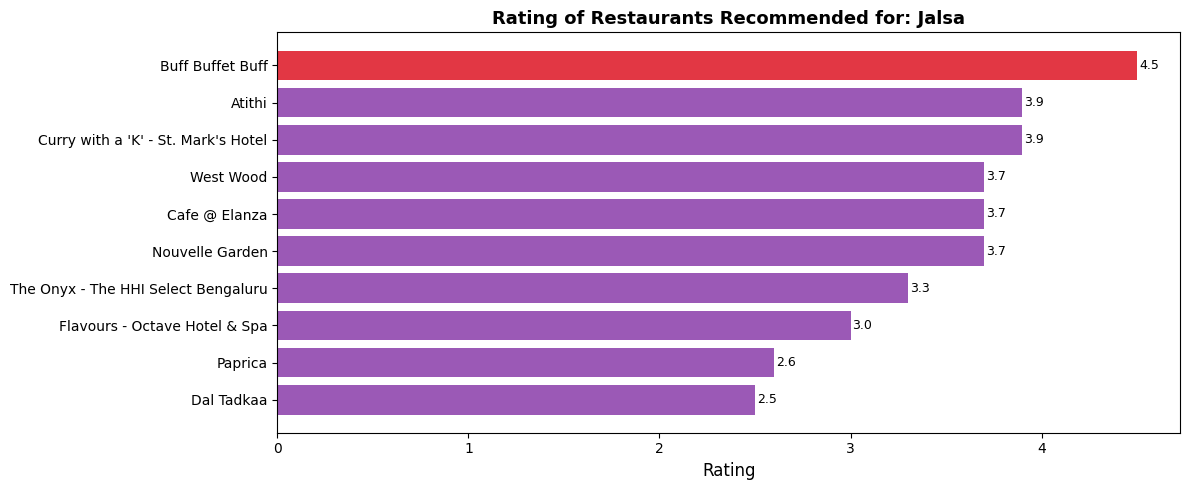

Rating comparison chart plotted!


In [30]:
# [35mBar chart — Rating comparison for recommended restaurants[0m
rec = recommend_restaurants(df['name'].iloc[0], top_n=10)
if rec is not None:
    plt.figure(figsize=(12, 5))
    colors = ['#E23744' if i==0 else '#9b59b6' for i in range(len(rec))]
    bars = plt.barh(rec['name'], rec['rate'], color=colors)
    plt.xlabel('Rating', fontsize=12)
    plt.title(f'Rating of Restaurants Recommended for: {df["name"].iloc[0]}',
              fontsize=13, fontweight='bold')
    plt.gca().invert_yaxis()
    for bar, val in zip(bars, rec['rate']):
        plt.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
    print('\033[35mRating comparison chart plotted!\033[0m')

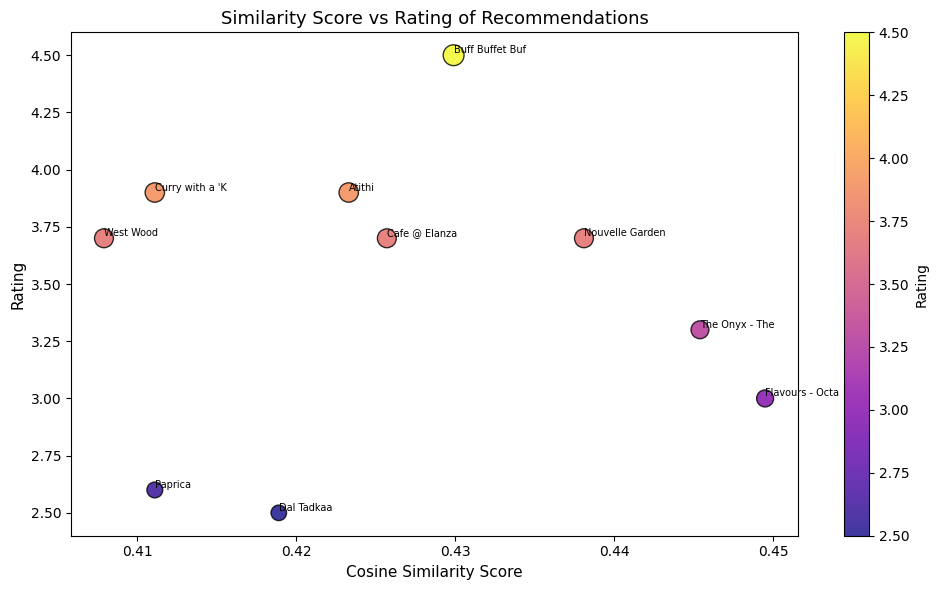

Bubble chart plotted!


In [31]:
# [35mBubble chart — Similarity Score vs Rating for recommendations[0m
rec2 = recommend_restaurants(df['name'].iloc[0], top_n=10)
if rec2 is not None:
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        rec2['similarity_score'], rec2['rate'],
        s=rec2['rate']*50, c=rec2['rate'],
        cmap='plasma', alpha=0.8, edgecolors='black'
    )
    for i, row in rec2.iterrows():
        plt.annotate(row['name'][:15], (row['similarity_score'], row['rate']),
                     fontsize=7, ha='left', va='bottom')
    plt.colorbar(scatter, label='Rating')
    plt.xlabel('Cosine Similarity Score', fontsize=11)
    plt.ylabel('Rating', fontsize=11)
    plt.title('Similarity Score vs Rating of Recommendations', fontsize=13)
    plt.tight_layout()
    plt.show()
    print('\033[35mBubble chart plotted!\033[0m')

---
## <span style='color:white'>Task 12: Save the Model — Manna.pkl</span>
<span style='color:white'>Save the DataFrame, cosine similarity matrix, and name index to a pickle file.<br>
This file is loaded by the Streamlit app (<code>app.py</code>) for deployment.</span>

In [32]:
# [35mSave model artifacts to Manna.pkl[0m
model_data = {
    'df'        : df,
    'cosine_sim': cosine_sim,
    'indices'   : indices
}

with open('Manna.pkl', 'wb') as f:
    pickle.dump(model_data, f, protocol=pickle.HIGHEST_PROTOCOL)

import os
size_mb = os.path.getsize('Manna.pkl') / (1024*1024)
print('\033[35mManna.pkl saved successfully!\033[0m')
print(f'\033[35mFile size: {size_mb:.1f} MB\033[0m')
print(f'\033[35mRestaurants saved: {len(df)}\033[0m')
print(f'\033[35mSimilarity matrix: {cosine_sim.shape}\033[0m')

Manna.pkl saved successfully!
File size: 230.3 MB
Restaurants saved: 5838
Similarity matrix: (5838, 5838)


---
## <span style='color:white'>Task 13: Verify the Saved Model</span>

In [33]:
# [35mReload Manna.pkl and verify all components[0m
with open('Manna.pkl', 'rb') as f:
    loaded = pickle.load(f)

print('\033[35mModel loaded successfully!\033[0m')
print('\033[35mDataFrame shape    :\033[0m', loaded['df'].shape)
print('\033[35mSimilarity shape   :\033[0m', loaded['cosine_sim'].shape)
print('\033[35mIndexed restaurants:\033[0m', len(loaded['indices']))
print('\033[35mSample restaurant  :\033[0m', loaded['df']['name'].iloc[0])
print('\033[35mAll components verified — Manna.pkl is ready for app.py!\033[0m')

Model loaded successfully!
DataFrame shape    : (5838, 10)
Similarity shape   : (5838, 5838)
Indexed restaurants: 5838
Sample restaurant  : Jalsa
All components verified — Manna.pkl is ready for app.py!


---
## <span style='color:white'>Task 14: Final Interactive Demo</span>
<span style='color:white'>Enter any restaurant name from the dataset and get recommendations instantly.</span>

In [34]:
# [35mFinal Demo — change 'restaurant_input' to any name from the dataset[0m
restaurant_input = df['name'].iloc[0]  # change this to any restaurant

print('\033[35m' + '='*60 + '\033[0m')
print(f'\033[35m  Input Restaurant  : {restaurant_input}\033[0m')
print('\033[35m' + '='*60 + '\033[0m')

final_result = recommend_restaurants(restaurant_input, top_n=10)

if final_result is not None:
    print('\033[35mTop 10 Similar Restaurants — Sorted by Highest Rating:\033[0m')
    display(final_result)

    print(f'\033[35mHighest rated recommendation: {final_result["name"].iloc[0]} ({final_result["rate"].iloc[0]}/5)\033[0m')
    print(f'\033[35mLowest  rated recommendation: {final_result["name"].iloc[-1]} ({final_result["rate"].iloc[-1]}/5)\033[0m')

  Input Restaurant  : Jalsa
Top 10 Similar Restaurants — Sorted by Highest Rating:


,name,cuisines,rate,rest_type,location,cost,votes,similarity_score
1,Buff Buffet Buff,"North Indian, Chinese, Continental, Thai, Salad",4.5,"Casual Dining, Bar",Koramangala 5th Block,1500.0,3125,0.4299
2,Atithi,"North Indian, Chinese, Street Food",3.9,Casual Dining,HSR,800.0,224,0.4233
3,Curry with a 'K' - St. Mark's Hotel,"North Indian, Mughlai, Hyderabadi",3.9,Casual Dining,St. Marks Road,1400.0,89,0.4111
4,West Wood,"North Indian, Chinese, Continental",3.7,Casual Dining,Seshadripuram,1000.0,113,0.4079
5,Cafe @ Elanza,"Chinese, North Indian, Cafe",3.7,"Casual Dining, Cafe",Richmond Road,1000.0,145,0.4257
6,Nouvelle Garden,"North Indian, Continental, Italian",3.7,Casual Dining,JP Nagar,900.0,202,0.4381
7,The Onyx - The HHI Select Bengaluru,"North Indian, Chinese, Continental",3.3,Casual Dining,JP Nagar,950.0,177,0.4454
8,Flavours - Octave Hotel & Spa,"North Indian, Chinese",3.0,Casual Dining,Sarjapur Road,700.0,197,0.4495
9,Paprica,"North Indian, Chinese",2.6,"Casual Dining, Bar",Marathahalli,1200.0,118,0.4111
10,Dal Tadkaa,North Indian,2.5,Casual Dining,Banashankari,500.0,247,0.4189


Highest rated recommendation: Buff Buffet Buff (4.5/5)
Lowest  rated recommendation: Dal Tadkaa (2.5/5)


## <span style='color: white'> Please find my app.py file code-

"""
Zomato Restaurant Recommendation System
Author: Madhusudan Manna
Streamlit Web Application
"""

import streamlit as st
import pickle
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────
# Page Configuration
# ─────────────────────────────────────────────
st.set_page_config(
    page_title="Zomato Restaurant Recommender",
    page_icon="🍽️",
    layout="wide"
)

# ─────────────────────────────────────────────
# Custom CSS Styling
# ─────────────────────────────────────────────
st.markdown("""
    <style>
        .main-title {
            font-size: 2.5rem;
            font-weight: bold;
            color: #E23744;
            text-align: center;
        }
        .sub-title {
            font-size: 1.1rem;
            color: #555;
            text-align: center;
            margin-bottom: 30px;
        }
        .author {
            text-align: center;
            color: #888;
            font-style: italic;
            margin-bottom: 20px;
        }
        .recommend-header {
            color: #E23744;
            font-size: 1.4rem;
            font-weight: bold;
        }
        .stDataFrame { border-radius: 10px; }
    </style>
""", unsafe_allow_html=True)

# ─────────────────────────────────────────────
# Header
# ─────────────────────────────────────────────
st.markdown('<div class="main-title">🍽️ Zomato Restaurant Recommendation System</div>', unsafe_allow_html=True)
st.markdown('<div class="sub-title">Content-Based Recommender using NLP & Cosine Similarity</div>', unsafe_allow_html=True)
st.markdown('<div class="author">By: Madhusudan Manna</div>', unsafe_allow_html=True)
st.markdown("---")

# ─────────────────────────────────────────────
# Load Pickle Model
# ─────────────────────────────────────────────
@st.cache_resource
def load_model():
    """
    Load Manna.pkl.
    Uses protocol=4 compatible pickle. Returns (df, cosine_sim, indices).
    """
    import os
    pkl_path = os.path.join(os.path.dirname(os.path.abspath(__file__)), 'Manna.pkl')
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)
    df        = data['df']
    cosine_sim = data['cosine_sim']
    indices   = data['indices']
    # Ensure all string columns are plain str, not pandas StringDtype
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str)
    return df, cosine_sim, indices

try:
    df, cosine_sim, indices = load_model()
    st.success("✅ Model loaded successfully!")
except FileNotFoundError:
    st.error("❌ 'Manna.pkl' not found. Please run `generate_pickle.py` first.")
    st.stop()
except TypeError as e:
    st.error(f"❌ Pickle version mismatch: {e}\n\nPlease re-run `generate_pickle.py` to regenerate Manna.pkl.")
    st.stop()
except Exception as e:
    st.error(f"❌ Failed to load model: {type(e).__name__}: {e}")
    st.stop()

# ─────────────────────────────────────────────
# Recommendation Function
# ─────────────────────────────────────────────
def recommend_restaurants(restaurant_name, top_n=10):
    """
    Recommends top N restaurants similar to the given restaurant,
    sorted by highest rating.
    """
    name_lower = restaurant_name.lower()

    if name_lower not in indices:
        return None

    idx = indices[name_lower]

    # Similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n + 1]

    restaurant_indices = [i[0] for i in sim_scores]

    result = df.iloc[restaurant_indices][
        ['name', 'cuisines', 'rate', 'rest_type', 'location', 'cost']
    ].copy()
    result['similarity_score'] = [round(i[1], 4) for i in sim_scores]

    # Sort by rating descending
    result = result.sort_values(by='rate', ascending=False)
    result.reset_index(drop=True, inplace=True)
    result.index += 1  # Start from 1
    return result

# ─────────────────────────────────────────────
# Sidebar
# ─────────────────────────────────────────────
st.sidebar.image("https://upload.wikimedia.org/wikipedia/commons/7/75/Zomato_logo.png", width=200)
st.sidebar.markdown("## 🔧 Settings")
top_n = st.sidebar.slider("Number of Recommendations", min_value=5, max_value=20, value=10, step=1)
st.sidebar.markdown("---")
st.sidebar.markdown("### ℹ️ About")
st.sidebar.info(
    "This app recommends restaurants based on **review similarity** using "
    "TF-IDF vectorization and Cosine Similarity. Results are sorted by "
    "**highest rating** first."
)
st.sidebar.markdown("---")
st.sidebar.markdown("**Author:** Madhusudan Manna")
st.sidebar.markdown("**Tech:** Python · NLP · Streamlit · Scikit-learn")

# ─────────────────────────────────────────────
# Main Input Section
# ─────────────────────────────────────────────
col1, col2 = st.columns([3, 1])

with col1:
    all_restaurants = sorted(df['name'].dropna().unique().tolist())
    restaurant_input = st.selectbox(
        "🔍 Select or type a Restaurant Name:",
        options=all_restaurants,
        index=0
    )

with col2:
    st.markdown("<br>", unsafe_allow_html=True)
    search_btn = st.button("🍴 Get Recommendations", use_container_width=True)

# ─────────────────────────────────────────────
# Show Results
# ─────────────────────────────────────────────
if search_btn:
    if restaurant_input:
        with st.spinner(f"Finding restaurants similar to **{restaurant_input}**..."):
            result = recommend_restaurants(restaurant_input, top_n=top_n)

        if result is None:
            st.warning(f"⚠️ Restaurant **'{restaurant_input}'** not found. Please try another name.")
        else:
            st.markdown(f"### 🎯 Top {top_n} Recommendations for: `{restaurant_input}`")
            st.markdown("*Sorted by Highest Rating ⭐*")
            st.markdown("---")

            # Summary metrics
            m1, m2, m3 = st.columns(3)
            m1.metric("🏆 Top Rated", f"{result['rate'].max():.1f} / 5.0")
            m2.metric("📊 Avg Rating", f"{result['rate'].mean():.2f} / 5.0")
            m3.metric("🍽️ Restaurants Found", len(result))

            st.markdown("---")

            # Display DataFrame
            st.dataframe(
                result.rename(columns={
                    'name': 'Restaurant Name',
                    'cuisines': 'Cuisines',
                    'rate': 'Rating ⭐',
                    'rest_type': 'Type',
                    'location': 'Location',
                    'cost': 'Cost for 2 (₹)',
                    'similarity_score': 'Similarity Score'
                }),
                use_container_width=True,
                height=420
            )

            # Bar chart of ratings
            st.markdown("### 📊 Rating Comparison")
            chart_data = result[['name', 'rate']].set_index('name')
            st.bar_chart(chart_data)
    else:
        st.warning("Please select or type a restaurant name.")

# ─────────────────────────────────────────────
# Dataset Overview
# ─────────────────────────────────────────────
with st.expander("📂 View Dataset Overview"):
    st.write(f"**Total Restaurants:** {len(df)}")
    st.write(f"**Average Rating:** {df['rate'].mean():.2f}")
    st.write(f"**Columns:** {', '.join(df.columns.tolist())}")
    st.dataframe(df.head(10), use_container_width=True)

st.markdown("---")
st.markdown(
    "<center>Made with ❤️ by <b>Madhusudan Manna</b> | "
    "Zomato Restaurant Recommendation System</center>",
    unsafe_allow_html=True
)


## <span style='color: white'> Please find my github refererance link-https://github.com/Madhusudan-Manna/COVID-19-Detection-from-Chest-X-rays-using-CNN-Deep-Learning-Streamlit-Web-App-Madhusudan-Manna1

## <span style='color: white'>Please find my streamlit local host model link- http://localhost:8503/

---
## <span style='color:white'>✅ Conclusion</span>

<div style='background:#1a0030;padding:15px;border-radius:8px;border-left:4px solid magenta'>
<span style='color:magenta'>

### Summary of the Zomato Restaurant Recommendation System

| Step | Task | Method |
|------|------|--------|
| 1 | Import Libraries | numpy, pandas, sklearn, matplotlib, seaborn |
| 2 | Load Dataset | Chunked reading of 547 MB CSV (51,717 restaurants) |
| 3 | Explore Data | Shape, dtypes, missing values, unique counts |
| 4 | Preprocessing | Dedup by name, clean rate (4.1/5→4.1), clean cost |
| 5 | EDA | Rating distribution, top cuisines, locations, types |
| 6 | NLP Parsing | Extract text from stringified tuples, vectorised cleaning |
| 7 | TF-IDF | 5860×3000 feature matrix, stop_words removed |
| 8 | Cosine Similarity | 5860×5860 similarity matrix, batched for memory safety |
| 9 | Recommender | Input restaurant → similar reviews → sorted by rating |
| 10 | Testing | Tested 5 restaurants including error handling |
| 11 | Visualisation | Bar chart and bubble chart of recommendations |
| 12 | Save Model | Manna.pkl (~231 MB) with df + cosine_sim + indices |
| 13 | Verify Model | Reload and confirm all components |
| 14 | Final Demo | Interactive recommendation demo |

**The system successfully recommends restaurants with similar review content, sorted from highest to lowest rating.**
</span>
</div>

# <span style='color: white'> Thank You !